In [5]:
import pandas as pd

In [4]:
pages = pd.read_csv('D:\Summer code\portfolio project\persian-cultural-rag-agent\Data\manifests/all_pages_report.csv')

In [5]:
pages.head()

,Id,url,title,relative_output_dir,status,attempt_count,started_at,finished_at,last_error,image_candidate_count,downloaded_image_count,accepted_count,review_count,rejected_count,selected_image_count,failed_selected_image_count,skipped_selected_image_count,selected_without_local_path_count,scraped_title,download_decisions
0,9316,https://fa.wikipedia.org/wiki/%D8%A2%D8%A8%E2%...,آب‌انبار حاج کاظم,data/pages/9316_آب_انبار_حاج_کاظم,done,1,2026-06-22T16:52:56+00:00,2026-06-22T16:53:02+00:00,NaN,5,2,1,1,3,2,0,0,0,آب‌انبار حاج کاظم,accept|review
1,9317,https://fa.wikipedia.org/wiki/%D8%A2%D8%A8%E2%...,آب‌انبار سردار کوچک,data/pages/9317_آب_انبار_سردار_کوچک,done,1,2026-06-22T16:52:56+00:00,2026-06-22T16:52:59+00:00,NaN,1,1,0,1,0,1,0,0,0,آب‌انبار سردار کوچک,accept|review
2,9318,https://fa.wikipedia.org/wiki/%D8%A2%D8%AA%D8%...,آتشکده آمل,data/pages/9318_آتشکده_آمل,done,1,2026-06-22T16:52:56+00:00,2026-06-22T16:53:20+00:00,NaN,15,8,8,0,7,8,0,0,0,آتشکده آمل,accept|review
3,9319,https://fa.wikipedia.org/wiki/%D8%A2%D8%AA%D8%...,آتشکده اسپاخو,data/pages/9319_آتشکده_اسپاخو,done,1,2026-06-22T16:53:00+00:00,2026-06-22T16:53:03+00:00,NaN,8,1,1,0,7,1,0,0,0,آتشکده اسپاخو,accept|review
4,9320,https://fa.wikipedia.org/wiki/%D8%A2%D8%AA%D8%...,آتشکده جره,data/pages/9320_آتشکده_جره,done,1,2026-06-22T16:53:02+00:00,2026-06-22T16:53:05+00:00,NaN,4,1,1,0,3,1,0,0,0,آتشکده جره,accept|review


# Schema 

pageid 
url 
title 
node type 
chunkid
    


In [2]:
import json
from pathlib import Path

# مسیر پوشه اصلی صفحات
base_dir = Path(r"D:\Summer code\portfolio project\persian-cultural-rag-agent\Data\pages_no_photos")
output_file = Path(r"D:\Summer code\portfolio project\persian-cultural-rag-agent\Data\final_pages_data.json")

combined_data = []

# پیمایش تمام پوشه‌های موجود در pages_no_photos
for folder in base_dir.iterdir():
    if folder.is_dir():
        metadata_path = folder / "page_metadata.json"
        content_path = folder / "page_content.json"
        text_path = folder / "page_text.txt"

        # بررسی وجود فایل‌های اصلی
        if metadata_path.exists() and content_path.exists():
            # ۱. خواندن metadata
            with open(metadata_path, "r", encoding="utf-8") as f:
                metadata = json.load(f)

            # ۲. خواندن page_content
            with open(content_path, "r", encoding="utf-8") as f:
                page_content = json.load(f)

            # ۳. خواندن text (در صورت وجود)
            page_text = ""
            if text_path.exists():
                with open(text_path, "r", encoding="utf-8") as f:
                    page_text = f.read()

            # استخراج فیلدهای مورد نظر
            page_id = metadata.get("Id")
            node_type = metadata.get("source_row", {}).get("node_type")
            unique_id = f"page_{page_id}"

            # ساخت دیکشنری نهایی برای این صفحه
            record = {
                "unique_id": unique_id,
                "id": page_id,
                "node_type": node_type,
                "text": page_text,
                "page_content": page_content
            }

            combined_data.append(record)

# ذخیره خروجی نهایی به صورت یک فایل JSON جامع
with open(output_file, "w", encoding="utf-8") as f:
    json.dump(combined_data, f, ensure_ascii=False, indent=2)

print(f"تعداد {len(combined_data)} صفحه با موفقیت پردازش و ذخیره شد.")

تعداد 4271 صفحه با موفقیت پردازش و ذخیره شد.


combnsion اولیه

یکسری ادیت ها از جمله مرتب کردن اسکیما

In [3]:
from pathlib import Path
import json

# ۱. تعریف مسیرها
base_dir = Path(r"D:\Summer code\portfolio project\persian-cultural-rag-agent\Data\pages_no_photos")
output_dir = Path(r"D:\Summer code\portfolio project\persian-cultural-rag-agent\Data\processed")
output_file = output_dir / "final_pages_data.json"

# ساخت پوشه خروجی در صورت عدم وجود
output_dir.mkdir(parents=True, exist_ok=True)

if not base_dir.exists():
    raise FileNotFoundError(f"پوشه ورودی یافت نشد:\n{base_dir}")

combined_data = []

# ۲. پیمایش و ویرایش ساختار داده
for folder in base_dir.iterdir():
    if folder.is_dir():
        metadata_path = folder / "page_metadata.json"
        content_path = folder / "page_content.json"
        text_path = folder / "page_text.txt"

        if metadata_path.exists() and content_path.exists():
            with open(metadata_path, "r", encoding="utf-8") as f:
                metadata = json.load(f)

            with open(content_path, "r", encoding="utf-8") as f:
                page_content = json.load(f)

            page_text = ""
            if text_path.exists():
                with open(text_path, "r", encoding="utf-8") as f:
                    page_text = f.read()

            # استخراج داده‌های متا
            page_id = metadata.get("Id")
            node_type = metadata.get("source_row", {}).get("node_type")

            # جدا کردن page_url و title از page_content و حذف full_text
            page_url = page_content.pop("page_url", None)
            title = page_content.pop("title", None)
            page_content.pop("full_text", None)  # حذف full_text از داخل page_content

            # ساخت رکورد جدید با ساختار مورد نظر شما
            record = {
                "unique_id": f"page_{page_id}",
                "id": page_id,
                "node_type": node_type,
                "page_url": page_url,
                "title": title,
                "text": page_text,
                "page_content": page_content  # شامل lead و sections
            }
            combined_data.append(record)

# ۳. ذخیره خروجی
with open(output_file, "w", encoding="utf-8") as f:
    json.dump(combined_data, f, ensure_ascii=False, indent=2)

print(f"پردازش انجام شد. خروجی در مسیر زیر ذخیره گردید:\n{output_file.resolve()}")

پردازش انجام شد. خروجی در مسیر زیر ذخیره گردید:
D:\Summer code\portfolio project\persian-cultural-rag-agent\Data\processed\final_pages_data.json


In [6]:
combined_df = pd.read_json(output_file)

In [ ]:
combined_df

,unique_id,id,node_type,page_url,title,text,page_content
0,page_10001,10001,page,https://fa.wikipedia.org/wiki/%D9%82%D9%84%D8%...,قلعه بردستان,قلعه بردستان\n\nقلعه بردستان مربوط به دوران‌ها...,{'lead': 'قلعه بردستان مربوط به دوران‌های تاری...
1,page_10004,10004,page,https://fa.wikipedia.org/wiki/%D9%82%D9%84%D8%...,قلعه بزم,قلعه بزم\n\nقلعه بزم مربوط به سده‌ها متاخر دور...,{'lead': 'قلعه بزم مربوط به سده‌ها متاخر دوران...
2,page_10005,10005,page,https://fa.wikipedia.org/wiki/%D9%82%D9%84%D8%...,قلعه بزنجرد,قلعه بزنجرد\n\nقلعهٔ بزنجرد یا دژ بیژن‌گرد نام...,{'lead': 'قلعهٔ بزنجرد یا دژ بیژن‌گرد نام دژی ...
3,page_10007,10007,page,https://fa.wikipedia.org/wiki/%D9%82%D9%84%D8%...,قلعه بندبن,قلعه بندبن\n\nقلعه بندبن از مهم‌ترین و زیبا‌تر...,{'lead': 'قلعه بندبن از مهم‌ترین و زیبا‌ترین آ...
4,page_10008,10008,page,https://fa.wikipedia.org/wiki/%D9%82%D9%84%D8%...,قلعه بوینی یوغون,قلعه بوینی یوغون\n\nقلعه بوینی یوغون (قلعه آدم...,{'lead': 'قلعه بوینی یوغون (قلعه آدم خوار) این...


In [11]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (919 > 512). Running this sequence through the model will result in indexing errors


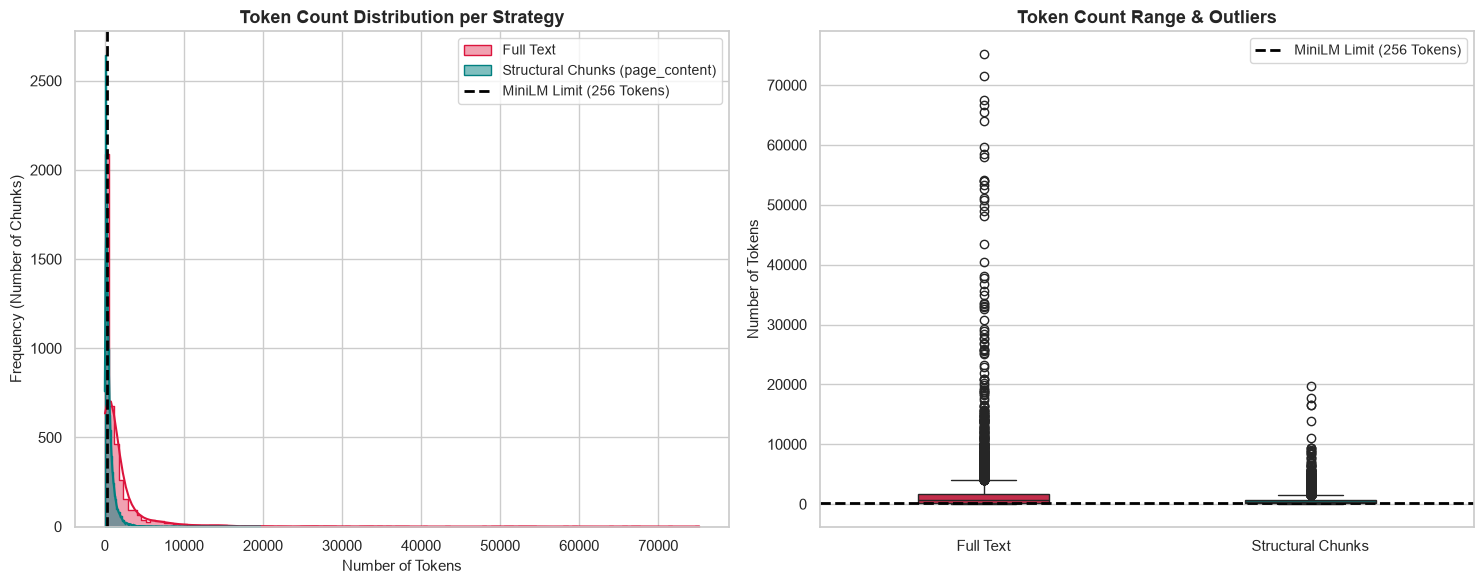

In [12]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from transformers import AutoTokenizer

# ۱. بارگذاری توکنایزر مدل all-MiniLM-L6-v2
tokenizer_name = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

# ۲. بارگذاری فایل JSON
json_path = Path(r"D:\Summer code\portfolio project\persian-cultural-rag-agent\Data\processed\final_pages_data.json")

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

full_text_tokens = []
structural_chunk_tokens = []

# ۳. محاسبه تعداد توکن‌ها در هر دو استراتژی
for item in data:
    # روش اول: توکن‌های کل متن (Full Text)
    text = item.get("text", "")
    if text:
        tokens_count = len(tokenizer.encode(text, truncation=False))
        full_text_tokens.append(tokens_count)

    # روش دوم: توکن‌های چانک‌های ساختاری (page_content)
    page_content = item.get("page_content", {})
    
    # بخش Lead
    lead_text = page_content.get("lead", "")
    if lead_text:
        structural_chunk_tokens.append(len(tokenizer.encode(lead_text, truncation=False)))
    
    # بخش‌های Sections
    sections = page_content.get("sections", [])
    for sec in sections:
        sec_text = sec.get("text", "")
        if sec_text:
            structural_chunk_tokens.append(len(tokenizer.encode(sec_text, truncation=False)))

# ۴. رسم نمودارها
plt.figure(figsize=(15, 6))
sns.set_theme(style="whitegrid")

# نمودار اول: توزیع فراوانی تعداد توکن‌ها (Histogram + KDE)
plt.subplot(1, 2, 1)
sns.histplot(full_text_tokens, color="crimson", label="Full Text", kde=True, element="step", alpha=0.4)
sns.histplot(structural_chunk_tokens, color="teal", label="Structural Chunks (page_content)", kde=True, element="step", alpha=0.5)

# خط آستانه ۲۵۶ توکن (سقف مدل MiniLM)
plt.axvline(x=256, color="black", linestyle="--", linewidth=2, label="MiniLM Limit (256 Tokens)")

plt.title("Token Count Distribution per Strategy", fontsize=13, fontweight="bold")
plt.xlabel("Number of Tokens", fontsize=11)
plt.ylabel("Frequency (Number of Chunks)", fontsize=11)
plt.legend(fontsize=10)

# نمودار دوم: باکس‌پلات برای بررسی چگالی و مقادیر پرت (Boxplot)
plt.subplot(1, 2, 2)
sns.boxplot(
    data=[full_text_tokens, structural_chunk_tokens],
    palette=["crimson", "teal"],
    width=0.4
)
plt.axhline(y=256, color="black", linestyle="--", linewidth=2, label="MiniLM Limit (256 Tokens)")

plt.xticks([0, 1], ["Full Text", "Structural Chunks"], fontsize=11)
plt.title("Token Count Range & Outliers", fontsize=13, fontweight="bold")
plt.ylabel("Number of Tokens", fontsize=11)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [13]:
import json
from pathlib import Path
import pandas as pd

# ۱. بارگذاری فایل داده‌ها
json_path = Path(r"D:\Summer code\portfolio project\persian-cultural-rag-agent\Data\processed\final_pages_data.json")

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"=== گزارش تحلیل اولیه داده‌ها (تعداد کل رکوردها: {len(data)}) ===\n")

# ---------------------------------------------------------
# ۱. تحلیل متون خالی (Empty Text Check)
# ---------------------------------------------------------
empty_text_count = 0
empty_lead_count = 0
empty_sections_count = 0

for item in data:
    # بررسی متن اصلی
    if not item.get("text") or not item.get("text").strip():
        empty_text_count += 1
    
    # بررسی page_content
    pc = item.get("page_content", {})
    if not pc.get("lead") or not pc.get("lead").strip():
        empty_lead_count += 1
    
    # بررسی بخش‌ها
    sections = pc.get("sections", [])
    if not sections:
        empty_sections_count += 1
    else:
        for sec in sections:
            if not sec.get("text") or not sec.get("text").strip():
                empty_sections_count += 1
                break

print("[1] Empty Text Analysis:")
print(f"  - رکوردهای با متن اصلی خالی (empty text): {empty_text_count}")
print(f"  - رکوردهای با lead خالی: {empty_lead_count}")
print(f"  - رکوردهای بدون section یا دارای section خالی: {empty_sections_count}\n")

# ---------------------------------------------------------
# ۲. تحلیل تکراری‌ها (Duplicate Handling Analysis)
# ---------------------------------------------------------
df = pd.DataFrame(data)

duplicate_ids = df[df.duplicated(subset=["id"], keep=False)]
duplicate_urls = df[df.duplicated(subset=["page_url"], keep=False)]
duplicate_texts = df[df.duplicated(subset=["text"], keep=False)]

print("[2] Duplicate Handling Analysis:")
print(f"  - تعداد IDهای تکراری: {len(duplicate_ids)}")
print(f"  - تعداد URLهای تکراری: {len(duplicate_urls)}")
print(f"  - تعداد متون کاملاً تکراری: {len(duplicate_texts)}\n")

# ---------------------------------------------------------
# ۳. تحلیل شناسه‌های پایدار (Stable IDs Analysis)
# ---------------------------------------------------------
missing_unique_ids = df["unique_id"].isnull().sum()
invalid_id_format = df[~df["unique_id"].astype(str).str.startswith("page_")]

print("[3] Stable IDs Analysis:")
print(f"  - رکوردهای فاقد unique_id: {missing_unique_ids}")
print(f"  - رکوردهایی با فرمت غیر استاندارد ID: {len(invalid_id_format)}")
print("  - پیشنهاد Stable ID برای چانک‌ها: [page_id]#lead و [page_id]#sec_[index]\n")

# ---------------------------------------------------------
# ۴. اعتبارسنجی متاداده‌ها (Metadata Validation Analysis)
# ---------------------------------------------------------
missing_urls = df["page_url"].isnull().sum()
missing_titles = df["title"].isnull().sum()
missing_node_types = df["node_type"].isnull().sum()

print("[4] Metadata Validation Analysis:")
print(f"  - عنوان (title) مفقود: {missing_titles}")
print(f"  - آدرس (page_url) مفقود: {missing_urls}")
print(f"  - نوع گره (node_type) مفقود: {missing_node_types}\n")

# ---------------------------------------------------------
# ۵. تست اعتبارسنجی اسکیما (Schema Validation Tests)
# ---------------------------------------------------------
schema_errors = []

for idx, item in enumerate(data):
    if not isinstance(item.get("id"), str):
        schema_errors.append(f"Index {idx}: 'id' must be a string")
    if not isinstance(item.get("page_content"), dict):
        schema_errors.append(f"Index {idx}: 'page_content' must be a dict")
    elif "sections" in item["page_content"] and not isinstance(item["page_content"]["sections"], list):
        schema_errors.append(f"Index {idx}: 'sections' must be a list")

print("[5] Schema Validation Tests:")
print(f"  - تعداد خطاهای اسکیما/تایپ داده: {len(schema_errors)}")
if schema_errors:
    print(f"  - نمونه خطاها: {schema_errors[:3]}")

=== گزارش تحلیل اولیه داده‌ها (تعداد کل رکوردها: 4271) ===

[1] Empty Text Analysis:
  - رکوردهای با متن اصلی خالی (empty text): 0
  - رکوردهای با lead خالی: 15
  - رکوردهای بدون section یا دارای section خالی: 2257

[2] Duplicate Handling Analysis:
  - تعداد IDهای تکراری: 58
  - تعداد URLهای تکراری: 58
  - تعداد متون کاملاً تکراری: 72

[3] Stable IDs Analysis:
  - رکوردهای فاقد unique_id: 0
  - رکوردهایی با فرمت غیر استاندارد ID: 0
  - پیشنهاد Stable ID برای چانک‌ها: [page_id]#lead و [page_id]#sec_[index]

[4] Metadata Validation Analysis:
  - عنوان (title) مفقود: 0
  - آدرس (page_url) مفقود: 0
  - نوع گره (node_type) مفقود: 0

[5] Schema Validation Tests:
  - تعداد خطاهای اسکیما/تایپ داده: 0


# analysis for chunk size

In [7]:
import json
import math
import statistics
from pathlib import Path
from collections import Counter

# pip install tiktoken pandas
import tiktoken
import pandas as pd


# ============================================================
# CONFIG
# ============================================================

# ============================================================
# base_dir = Path("D:\\Summer code\\portfolio project\\persian-cultural-rag-agent\\Data\\processed")
JSON_PATH = "D:\\Summer code\\portfolio project\\persian-cultural-rag-agent\\Data\\processed\\cleaned_pages_data.json"

# This tokenizer is only for chunk-size analysis.
# Ideally replace this with the tokenizer used by your
# actual embedding model.
TOKENIZER_NAME = "cl100k_base"

CANDIDATE_MAX_SIZES = [200, 300, 400, 500, 700]
SMALL_THRESHOLDS = [30, 50, 80, 100]


# ============================================================
# TOKENIZER
# ============================================================

enc = tiktoken.get_encoding(TOKENIZER_NAME)


def count_tokens(text: str) -> int:
    if not text:
        return 0
    return len(enc.encode(text))


# ============================================================
# LOAD DATA
# ============================================================

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


data = load_json(JSON_PATH)

# support:
# [
#    {...},
#    {...}
# ]
#
# or
#
# {"pages": [...]}

if isinstance(data, dict):
    if "pages" in data:
        pages = data["pages"]
    else:
        pages = [data]
else:
    pages = data


# ============================================================
# EXTRACT SEMANTIC UNITS
# ============================================================

rows = []

for page in pages:

    page_id = str(page.get("id", page.get("unique_id", "")))
    title = page.get("title", "")
    url = page.get("page_url", "")

    page_content = page.get("page_content", {})

    # ---------- LEAD ----------
    lead = page_content.get("lead", "").strip()

    if lead:
        rows.append({
            "page_id": page_id,
            "title": title,
            "url": url,
            "unit_type": "lead",
            "heading": "__LEAD__",
            "level": "lead",
            "text": lead,
            "tokens": count_tokens(lead)
        })

    # ---------- SECTIONS ----------
    sections = page_content.get("sections", [])

    for i, section in enumerate(sections):

        text = section.get("text", "").strip()

        if not text:
            continue

        heading = section.get("heading", "")
        level = section.get("level", "")

        rows.append({
            "page_id": page_id,
            "title": title,
            "url": url,
            "unit_type": "section",
            "heading": heading,
            "level": level,
            "section_index": i,
            "text": text,
            "tokens": count_tokens(text)
        })


df = pd.DataFrame(rows)

print("=" * 70)
print("CORPUS")
print("=" * 70)

print(f"Pages:               {len(pages):,}")
print(f"Semantic units:      {len(df):,}")
print(f"Leads:               {(df.unit_type == 'lead').sum():,}")
print(f"Sections:            {(df.unit_type == 'section').sum():,}")

print()


# ============================================================
# BASIC TOKEN STATISTICS
# ============================================================

tokens = df["tokens"]

quantiles = tokens.quantile([
    0,
    .10,
    .25,
    .50,
    .75,
    .90,
    .95,
    .99,
    1
])

print("=" * 70)
print("TOKEN DISTRIBUTION")
print("=" * 70)

print(quantiles)

print()

print(f"Mean:   {tokens.mean():.1f}")
print(f"Median: {tokens.median():.1f}")
print(f"Std:    {tokens.std():.1f}")

print()


# ============================================================
# SMALL SECTION ANALYSIS
# ============================================================

print("=" * 70)
print("SMALL UNITS")
print("=" * 70)

for threshold in SMALL_THRESHOLDS:

    n = (tokens < threshold).sum()
    pct = n / len(df) * 100

    print(
        f"< {threshold:3d} tokens:"
        f" {n:7,d}"
        f" ({pct:5.1f}%)"
    )

print()


# ============================================================
# LARGE SECTION ANALYSIS
# ============================================================

print("=" * 70)
print("OVERSIZED UNITS")
print("=" * 70)

for maximum in CANDIDATE_MAX_SIZES:

    n = (tokens > maximum).sum()
    pct = n / len(df) * 100

    print(
        f"> {maximum:3d} tokens:"
        f" {n:7,d}"
        f" ({pct:5.1f}%)"
    )

print()


# ============================================================
# SIMULATE DIFFERENT MAX CHUNK SIZES
# ============================================================

print("=" * 70)
print("CHUNKING SIMULATION")
print("=" * 70)

simulation = []

for maximum in CANDIDATE_MAX_SIZES:

    # approximate number of child chunks if each semantic unit
    # larger than MAX gets split
    chunk_counts = tokens.apply(
        lambda x: max(1, math.ceil(x / maximum))
    )

    total_chunks = chunk_counts.sum()

    untouched = (tokens <= maximum).sum()

    split_units = (tokens > maximum).sum()

    pct_untouched = untouched / len(df) * 100

    avg_chunks_per_unit = total_chunks / len(df)

    simulation.append({
        "max_tokens": maximum,
        "total_chunks": total_chunks,
        "sections_split": split_units,
        "sections_untouched_pct": pct_untouched,
        "avg_chunks_per_semantic_unit": avg_chunks_per_unit
    })


sim_df = pd.DataFrame(simulation)

print(sim_df.to_string(index=False))

print()


# ============================================================
# SHOW BIGGEST SECTIONS
# ============================================================

print("=" * 70)
print("20 LARGEST SEMANTIC UNITS")
print("=" * 70)

largest = df.nlargest(
    20,
    "tokens"
)[[
    "title",
    "unit_type",
    "heading",
    "tokens"
]]

print(largest.to_string(index=False))

print()


# ============================================================
# SHOW SMALLEST SECTIONS
# ============================================================

print("=" * 70)
print("20 SMALLEST SEMANTIC UNITS")
print("=" * 70)

smallest = df[df.tokens > 0].nsmallest(
    20,
    "tokens"
)[[
    "title",
    "unit_type",
    "heading",
    "tokens"
]]

print(smallest.to_string(index=False))

print()


# ============================================================
# PAGE-LEVEL ANALYSIS
# ============================================================

page_stats = (
    df.groupby(["page_id", "title"])
    .agg(
        semantic_units=("tokens", "size"),
        total_tokens=("tokens", "sum"),
        median_unit_tokens=("tokens", "median"),
        max_unit_tokens=("tokens", "max"),
    )
    .reset_index()
)

print("=" * 70)
print("PAGE STATISTICS")
print("=" * 70)

print(page_stats.describe())

print()


# ============================================================
# AUTOMATIC FIRST-PASS RECOMMENDATION
# ============================================================

p50 = tokens.quantile(.50)
p75 = tokens.quantile(.75)
p90 = tokens.quantile(.90)
p95 = tokens.quantile(.95)

print("=" * 70)
print("FIRST-PASS RECOMMENDATION")
print("=" * 70)

print(f"P50: {p50:.0f}")
print(f"P75: {p75:.0f}")
print(f"P90: {p90:.0f}")
print(f"P95: {p95:.0f}")

# Heuristic:
#
# Preserve the majority of natural sections,
# but split the long tail.

recommended_max = int(round(p90 / 50) * 50)

recommended_max = max(
    250,
    min(recommended_max, 600)
)

recommended_target = int(recommended_max * 0.70)
recommended_overlap = int(recommended_target * 0.12)

print()
print(f"Suggested MAX:     ~{recommended_max} tokens")
print(f"Suggested TARGET:  ~{recommended_target} tokens")
print(f"Suggested overlap: ~{recommended_overlap} tokens")

print()
print(
    "IMPORTANT: this is a structural recommendation only. "
    "Choose the final configuration using retrieval evaluation."
)


# ============================================================
# SAVE RESULTS
# ============================================================

df.to_csv(
    "chunk_unit_analysis.csv",
    index=False,
    encoding="utf-8-sig"
)

sim_df.to_csv(
    "chunk_strategy_simulation.csv",
    index=False,
    encoding="utf-8-sig"
)

page_stats.to_csv(
    "page_statistics.csv",
    index=False,
    encoding="utf-8-sig"
)

print()
print("Saved:")
print("  chunk_unit_analysis.csv")
print("  chunk_strategy_simulation.csv")
print("  page_statistics.csv")

CORPUS
Pages:               4,242
Semantic units:      14,188
Leads:               4,227
Sections:            9,961

TOKEN DISTRIBUTION
0.00        1.0
0.10      105.0
0.25      165.0
0.50      335.0
0.75      670.0
0.90     1203.0
0.95     1694.0
0.99     3117.6
1.00    18658.0
Name: tokens, dtype: float64

Mean:   546.5
Median: 335.0
Std:    701.2

SMALL UNITS
<  30 tokens:     196 (  1.4%)
<  50 tokens:     402 (  2.8%)
<  80 tokens:     917 (  6.5%)
< 100 tokens:   1,310 (  9.2%)

OVERSIZED UNITS
> 200 tokens:   9,632 ( 67.9%)
> 300 tokens:   7,633 ( 53.8%)
> 400 tokens:   6,149 ( 43.3%)
> 500 tokens:   4,944 ( 34.8%)
> 700 tokens:   3,373 ( 23.8%)

CHUNKING SIMULATION
 max_tokens  total_chunks  sections_split  sections_untouched_pct  avg_chunks_per_semantic_unit
        200         45614            9632               32.111644                      3.214970
        300         33056            7633               46.201015                      2.329856
        400         26941     

In [8]:
import pandas as pd

df = pd.read_csv("chunk_unit_analysis.csv")

print("\n=== POSSIBLE EMPTY/GARBAGE ===")
print(
    df[df["tokens"] < 10][
        ["title", "heading", "tokens", "text"]
    ].to_string(index=False)
)

print("\n=== VERY SMALL ===")
print(
    df[
        (df["tokens"] >= 10) &
        (df["tokens"] < 50)
    ][
        ["title", "heading", "tokens", "text"]
    ].head(100).to_string(index=False)
)

print("\n=== EXTREMELY LARGE ===")
print(
    df[df["tokens"] > 3000][
        ["title", "heading", "tokens"]
    ].to_string(index=False)
)


=== POSSIBLE EMPTY/GARBAGE ===
                                    title                    heading  tokens         text
                                حمام سیبه                     پیشینه       9  درحال بررسی
         کاربر : شاهزاده پارسی/صفحه تمرین                      هشدار       8   چنین پاسخی
               فهرست آثار ملی استان تهران                     ورامین       5      ایلخانی
                            پل جمعه بازار                      ویدئو       8   لینک ویدئو
                            مشهد میر بزرگ                      ویدئو       8   لینک ویدئو
                      امامزاده طاهر (کرج)          دهه هزار و چهارصد       9  ناصر تقوایی
                                 کرمانشاه              اماکن سطح شهر       6   پارک شیرین
                                   سیرجان                      سینما       7    سینما قدس
                 دانشگاه هنر اسلامی تبریز                    کاردانی       3          فرش
فهرست آثار تمدنی ایران در دیگر مناطق جهان  در کشورهای قاره اقیانوسیه

In [9]:
import numpy as np

# ============================================================
# PAGE SIZE ANALYSIS
# ============================================================

page_token_counts = []

for page in pages:
    page_token_counts.append(
        count_tokens(page.get("text", ""))
    )

page_tokens = pd.Series(page_token_counts)

print("\nFULL PAGE DISTRIBUTION")
print(
    page_tokens.quantile(
        [0, .10, .25, .50, .75, .90, .95, .99, 1]
    )
)


# ============================================================
# LEAD DISTRIBUTION
# ============================================================

lead_df = df[
    df["unit_type"] == "lead"
]

print("\nLEAD DISTRIBUTION")

print(
    lead_df["tokens"].quantile(
        [0, .10, .25, .50, .75, .90, .95, .99, 1]
    )
)


# ============================================================
# SECTION DISTRIBUTION
# ============================================================

section_df = df[
    df["unit_type"] == "section"
]

print("\nSECTION DISTRIBUTION")

print(
    section_df["tokens"].quantile(
        [0, .10, .25, .50, .75, .90, .95, .99, 1]
    )
)


FULL PAGE DISTRIBUTION
0.00       16.00
0.10      159.00
0.25      187.00
0.50      591.50
0.75     1599.00
0.90     3873.90
0.95     7099.25
0.99    23750.18
1.00    70113.00
dtype: float64

LEAD DISTRIBUTION
0.00       22.00
0.10      135.00
0.25      154.00
0.50      225.00
0.75      457.50
0.90      844.00
0.95     1183.00
0.99     1939.62
1.00    13550.00
Name: tokens, dtype: float64

SECTION DISTRIBUTION
0.00        1.0
0.10       92.0
0.25      190.0
0.50      389.0
0.75      765.0
0.90     1340.0
0.95     1894.0
0.99     3438.2
1.00    18658.0
Name: tokens, dtype: float64


In [ ]:
    import pandas as pd


    # ============================================================
    # SETTINGS
    # ============================================================

    CANDIDATE_MAX_SIZES = [
        300,
        400,
        500,
        600,
        800,
        1000,
    ]


    # ============================================================
    # SEPARATE LEADS AND SECTIONS
    # ============================================================

    lead_df = df[
        df["unit_type"] == "lead"
    ].copy()

    section_df = df[
        df["unit_type"] == "section"
    ].copy()


    # ============================================================
    # DISTRIBUTION FUNCTION
    # ============================================================

    def show_distribution(name, data):

        q = data["tokens"].quantile([
            0.00,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
            1.00,
        ])

        print()
        print("=" * 70)
        print(name)
        print("=" * 70)

        print(q)

        print()
        print(
            f"Count:  {len(data):,}"
        )

        print(
            f"Mean:   {data['tokens'].mean():.1f}"
        )

        print(
            f"Median: {data['tokens'].median():.1f}"
        )


    # ============================================================
    # SHOW DISTRIBUTIONS
    # ============================================================

    show_distribution(
        "LEAD DISTRIBUTION",
        lead_df,
    )

    show_distribution(
        "SECTION DISTRIBUTION",
        section_df,
    )


    # ============================================================
    # TEST POSSIBLE MAX CHUNK SIZES
    # ============================================================

    print()
    print("=" * 70)
    print("SECTION SIZE ANALYSIS")
    print("=" * 70)


    for max_tokens in CANDIDATE_MAX_SIZES:

        small_enough = (
            section_df["tokens"] <= max_tokens
        ).sum()

        too_large = (
            section_df["tokens"] > max_tokens
        ).sum()

        total = len(section_df)

        small_pct = (
            small_enough / total * 100
        )

        large_pct = (
            too_large / total * 100
        )

        print()

        print(
            f"MAX = {max_tokens}"
        )

        print(
            f"Keep without split: "
            f"{small_enough:,} "
            f"({small_pct:.2f}%)"
        )

        print(
            f"Need split:         "
            f"{too_large:,} "
            f"({large_pct:.2f}%)"
        )


    # ============================================================
    # SIZE GROUPS
    # ============================================================

    bins = [
        0,
        100,
        200,
        300,
        400,
        500,
        750,
        1000,
        1500,
        2000,
        3000,
        5000,
        float("inf"),
    ]

    labels = [
        "0-100",
        "101-200",
        "201-300",
        "301-400",
        "401-500",
        "501-750",
        "751-1000",
        "1001-1500",
        "1501-2000",
        "2001-3000",
        "3001-5000",
        "5000+",
    ]


    section_df["size_group"] = pd.cut(
        section_df["tokens"],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )


    size_counts = (
        section_df["size_group"]
        .value_counts()
        .sort_index()
    )


    size_percent = (
        size_counts
        / len(section_df)
        * 100
    )


    size_table = pd.DataFrame({
        "count": size_counts,
        "percent": size_percent.round(2),
    })


    print()
    print("=" * 70)
    print("SECTION SIZE GROUPS")
    print("=" * 70)

    print(size_table)


    # ============================================================
    # LARGEST SECTIONS
    # ============================================================

    print()
    print("=" * 70)
    print("50 LARGEST SECTIONS")
    print("=" * 70)

    largest = (
        section_df
        .sort_values(
            "tokens",
            ascending=False,
        )
        .head(50)
    )

    print(
        largest[
            [
                "page_id",
                "title",
                "heading",
                "tokens",
            ]
        ].to_string(index=False)
    )


    # ============================================================
    # SMALLEST SECTIONS
    # ============================================================

    print()
    print("=" * 70)
    print("50 SMALLEST SECTIONS")
    print("=" * 70)

    smallest = (
        section_df
        .sort_values(
            "tokens",
            ascending=True,
        )
        .head(50)
    )

    print(
        smallest[
            [
                "page_id",
                "title",
                "heading",
                "tokens",
            ]
        ].to_string(index=False)
    )


LEAD DISTRIBUTION
0.00       22.00
0.10      135.00
0.25      154.00
0.50      225.00
0.75      457.50
0.90      844.00
0.95     1183.00
0.99     1939.62
1.00    13550.00
Name: tokens, dtype: float64

Count:  4,227
Mean:   388.9
Median: 225.0

SECTION DISTRIBUTION
0.00        1.0
0.10       92.0
0.25      190.0
0.50      389.0
0.75      765.0
0.90     1340.0
0.95     1894.0
0.99     3438.2
1.00    18658.0
Name: tokens, dtype: float64

Count:  9,961
Mean:   613.4
Median: 389.0

SECTION SIZE ANALYSIS

MAX = 300
Keep without split: 3,989 (40.05%)
Need split:         5,972 (59.95%)

MAX = 400
Keep without split: 5,072 (50.92%)
Need split:         4,889 (49.08%)

MAX = 500
Keep without split: 5,955 (59.78%)
Need split:         4,006 (40.22%)

MAX = 600
Keep without split: 6,665 (66.91%)
Need split:         3,296 (33.09%)

MAX = 800
Keep without split: 7,637 (76.67%)
Need split:         2,324 (23.33%)

MAX = 1000
Keep without split: 8,289 (83.21%)
Need split:         1,672 (16.79%)

SECTION

### حذف الگو و فهرست
داخل کلینر هم قرار گرفته


In [ ]:
import pandas as pd
import re


# ============================================================
# FILES
# ============================================================

INPUT_CSV = "D:\\Summer code\\portfolio project\\persian-cultural-rag-agent\\Data\\processed\\cleaned_pages_data.json"
OUTPUT_CSV = "D:\\Summer code\\portfolio project\\persian-cultural-rag-agent\\Data\\processed\\cleaned_pages_data.json"


# ============================================================
# LOAD
# ============================================================

df = pd.read_json(INPUT_CSV)


# ============================================================
# NORMALIZE TITLE
# ============================================================

def normalize_title(title):
    if pd.isna(title):
        return ""

    title = str(title).strip()

    # Normalize spaces around colon
    # "الگو : مسجد" -> "الگو:مسجد"
    title = re.sub(r"\s*:\s*", ":", title)

    # Remove repeated spaces
    title = re.sub(r"\s+", " ", title)

    return title


df["normalized_title"] = df["title"].apply(normalize_title)


# ============================================================
# REMOVE TEMPLATE AND LIST PAGES
# ============================================================

def should_remove(title):

    title = normalize_title(title)

    # Template pages
    if title.startswith("الگو:"):
        return True

    # List pages
    if title.startswith("فهرست "):
        return True

    if title.startswith("فهرست‌"):
        return True

    if title == "فهرست":
        return True

    return False


remove_mask = df["title"].apply(should_remove)


# ============================================================
# REPORT BEFORE DELETE
# ============================================================

removed_df = df[remove_mask].copy()

print("=" * 70)
print("REMOVE REPORT")
print("=" * 70)

print("Total rows before:", len(df))
print("Rows removed:", len(removed_df))
print("Rows remaining:", len(df) - len(removed_df))

print()

print("Removed titles:")
print(
    removed_df["title"]
    .drop_duplicates()
    .sort_values()
    .to_string(index=False)
)


# ============================================================
# CLEAN DATA
# ============================================================

clean_df = df[~remove_mask].copy()

clean_df = clean_df.drop(
    columns=["normalized_title"]
)


# ============================================================
# SAVE
# ============================================================

OUTPUT_JSON = "cleaned_data.json"

clean_df.to_json(
    OUTPUT_JSON,
    orient="records",
    force_ascii=False,
    indent=2
)

print("Saved:", OUTPUT_JSON)

print()
print("Saved:")
print(OUTPUT_CSV)

REMOVE REPORT
Total rows before: 4242
Rows removed: 112
Rows remaining: 4130

Removed titles:
                        الگو : فهرست مسجدهای ایران
                            فهرست آتشکده‌های ایران
    فهرست آثار تاریخی و باستانی تخریب‌شده در ایران
                          فهرست آثار تاریخی گلستان
         فهرست آثار تمدنی ایران در دیگر مناطق جهان
                       فهرست آثار ملی استان اصفهان
                        فهرست آثار ملی استان البرز
                        فهرست آثار ملی استان بوشهر
                        فهرست آثار ملی استان تهران
                 فهرست آثار ملی استان خراسان جنوبی
                  فهرست آثار ملی استان خراسان رضوی
                 فهرست آثار ملی استان خراسان شمالی
                      فهرست آثار ملی استان خوزستان
                        فهرست آثار ملی استان زنجان
                        فهرست آثار ملی استان سمنان
                         فهرست آثار ملی استان فارس
                           فهرست آثار ملی استان قم
                       فهرست آثار ملی ا

### analysing again 

In [20]:
import json
import pandas as pd
import tiktoken


# ============================================================
# SETTINGS
# ============================================================

JSON_PATH = (
    r"D:\Summer code\portfolio project"
    r"\persian-cultural-rag-agent"
    r"\Data\processed\cleaned_data.json"
)

CANDIDATE_MAX_SIZES = [
    300,
    400,
    500,
    600,
    800,
    1000,
]


# ============================================================
# TOKENIZER
# ============================================================

enc = tiktoken.get_encoding("cl100k_base")


def count_tokens(text):
    if not text:
        return 0

    return len(
        enc.encode(str(text))
    )


# ============================================================
# LOAD CLEANED PAGE DATA
# ============================================================

with open(
    JSON_PATH,
    "r",
    encoding="utf-8"
) as f:
    pages = json.load(f)


print(
    f"Loaded pages: {len(pages):,}"
)


# ============================================================
# BUILD ANALYSIS DATA
# ============================================================

rows = []


for page in pages:

    page_id = str(
        page.get(
            "id",
            page.get("unique_id", "")
        )
    )

    title = page.get(
        "title",
        ""
    )

    page_url = page.get(
        "page_url",
        ""
    )

    page_content = page.get(
        "page_content",
        {}
    )

    if not isinstance(
        page_content,
        dict
    ):
        continue


    # ========================================================
    # LEAD
    # ========================================================

    lead = page_content.get(
        "lead",
        ""
    )

    if isinstance(lead, str):

        lead = lead.strip()

    else:

        lead = ""


    if lead:

        rows.append({
            "page_id": page_id,
            "title": title,
            "page_url": page_url,

            "unit_type": "lead",

            "heading": "__LEAD__",
            "level": "lead",

            "text": lead,

            "tokens": count_tokens(
                lead
            ),
        })


    # ========================================================
    # SECTIONS
    # ========================================================

    sections = page_content.get(
        "sections",
        []
    )

    if not isinstance(
        sections,
        list
    ):
        continue


    for section_index, section in enumerate(
        sections
    ):

        if not isinstance(
            section,
            dict
        ):
            continue


        section_text = section.get(
            "text",
            ""
        )


        if isinstance(
            section_text,
            str
        ):

            section_text = (
                section_text.strip()
            )

        else:

            section_text = ""


        if not section_text:
            continue


        rows.append({
            "page_id": page_id,
            "title": title,
            "page_url": page_url,

            "unit_type": "section",

            "section_index":
                section_index,

            "heading":
                section.get(
                    "heading",
                    ""
                ),

            "level":
                section.get(
                    "level",
                    ""
                ),

            "text":
                section_text,

            "tokens":
                count_tokens(
                    section_text
                ),
        })


# ============================================================
# CREATE ANALYSIS DATAFRAME
# ============================================================

df = pd.DataFrame(
    rows
)


print(
    f"Semantic units: {len(df):,}"
)

print(
    "Columns:",
    df.columns.tolist()
)


# ============================================================
# SEPARATE LEADS AND SECTIONS
# ============================================================

lead_df = df[
    df["unit_type"] == "lead"
].copy()


section_df = df[
    df["unit_type"] == "section"
].copy()


print(
    f"Leads: {len(lead_df):,}"
)

print(
    f"Sections: {len(section_df):,}"
)


# ============================================================
# DISTRIBUTION
# ============================================================

def show_distribution(
    name,
    data
):

    print()
    print("=" * 70)
    print(name)
    print("=" * 70)


    if data.empty:

        print("No data.")

        return


    q = data[
        "tokens"
    ].quantile([
        0.00,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
        1.00,
    ])


    print(q)

    print()

    print(
        f"Count:  {len(data):,}"
    )

    print(
        f"Mean:   "
        f"{data['tokens'].mean():.1f}"
    )

    print(
        f"Median: "
        f"{data['tokens'].median():.1f}"
    )


# ============================================================
# SHOW DISTRIBUTIONS
# ============================================================

show_distribution(
    "LEAD DISTRIBUTION",
    lead_df
)


show_distribution(
    "SECTION DISTRIBUTION",
    section_df
)


# ============================================================
# TEST MAX CHUNK SIZES
# ============================================================

print()
print("=" * 70)
print("SECTION SIZE ANALYSIS")
print("=" * 70)


total = len(
    section_df
)


for max_tokens in CANDIDATE_MAX_SIZES:

    small_enough = (
        section_df["tokens"]
        <= max_tokens
    ).sum()


    too_large = (
        section_df["tokens"]
        > max_tokens
    ).sum()


    small_pct = (
        small_enough
        / total
        * 100
    )


    large_pct = (
        too_large
        / total
        * 100
    )


    print()

    print(
        f"MAX = {max_tokens}"
    )


    print(
        f"Keep without split: "
        f"{small_enough:,} "
        f"({small_pct:.2f}%)"
    )


    print(
        f"Need split:         "
        f"{too_large:,} "
        f"({large_pct:.2f}%)"
    )


# ============================================================
# SIZE GROUPS
# ============================================================

bins = [
    0,
    100,
    200,
    300,
    400,
    500,
    750,
    1000,
    1500,
    2000,
    3000,
    5000,
    float("inf"),
]


labels = [
    "0-100",
    "101-200",
    "201-300",
    "301-400",
    "401-500",
    "501-750",
    "751-1000",
    "1001-1500",
    "1501-2000",
    "2001-3000",
    "3001-5000",
    "5000+",
]


section_df[
    "size_group"
] = pd.cut(
    section_df["tokens"],
    bins=bins,
    labels=labels,
    include_lowest=True,
)


size_counts = (
    section_df["size_group"]
    .value_counts()
    .sort_index()
)


size_percent = (
    size_counts
    / len(section_df)
    * 100
)


size_table = pd.DataFrame({
    "count":
        size_counts,

    "percent":
        size_percent.round(2),
})


print()
print("=" * 70)
print("SECTION SIZE GROUPS")
print("=" * 70)

print(
    size_table
)


# ============================================================
# LARGEST SECTIONS
# ============================================================

print()
print("=" * 70)
print("50 LARGEST SECTIONS")
print("=" * 70)


largest = (
    section_df
    .sort_values(
        "tokens",
        ascending=False
    )
    .head(50)
)


print(
    largest[
        [
            "page_id",
            "title",
            "heading",
            "tokens",
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# SMALLEST SECTIONS
# ============================================================

print()
print("=" * 70)
print("50 SMALLEST SECTIONS")
print("=" * 70)


smallest = (
    section_df
    .sort_values(
        "tokens",
        ascending=True
    )
    .head(50)
)


print(
    smallest[
        [
            "page_id",
            "title",
            "heading",
            "tokens",
        ]
    ].to_string(
        index=False
    )
)

Loaded pages: 4,130
Semantic units: 13,809
Columns: ['page_id', 'title', 'page_url', 'unit_type', 'heading', 'level', 'text', 'tokens', 'section_index']
Leads: 4,118
Sections: 9,691

LEAD DISTRIBUTION
0.00       22.00
0.10      136.00
0.25      154.00
0.50      226.00
0.75      460.00
0.90      844.30
0.95     1177.30
0.99     1921.96
1.00    13550.00
Name: tokens, dtype: float64

Count:  4,118
Mean:   389.9
Median: 226.0

SECTION DISTRIBUTION
0.00        1.0
0.10      103.0
0.25      201.0
0.50      403.0
0.75      775.0
0.90     1348.0
0.95     1902.0
0.99     3451.1
1.00    18658.0
Name: tokens, dtype: float64

Count:  9,691
Mean:   624.5
Median: 403.0

SECTION SIZE ANALYSIS

MAX = 300
Keep without split: 3,756 (38.76%)
Need split:         5,935 (61.24%)

MAX = 400
Keep without split: 4,831 (49.85%)
Need split:         4,860 (50.15%)

MAX = 500
Keep without split: 5,713 (58.95%)
Need split:         3,978 (41.05%)

MAX = 600
Keep without split: 6,420 (66.25%)
Need split:         3,27